# clustering days into groups based on 500 mb heights (or full variable datasets? can see how similar they are)

In [61]:
import xarray as xr
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.ndimage import uniform_filter1d
from minisom import MiniSom
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd

In [19]:
weather = xr.open_dataset('data/raw_data/heights.nc')

In [20]:
z = weather['z'].load()  # (time, lat, lon)

z = z.squeeze('pressure_level')

# day-of-year climatology
climo = z.groupby('valid_time.dayofyear').mean('valid_time')

# smooth climatology (cyclic!)
climo_vals = climo.values  # (dayofyear, lat, lon)

climo_smooth = uniform_filter1d(
    climo_vals,
    size=15,
    axis=0,
    mode='wrap'
)

climo = xr.DataArray(
    climo_smooth,
    dims=climo.dims,
    coords=climo.coords
)

# anomalies
doy = z['valid_time'].dt.dayofyear
anom = z - climo.sel(dayofyear=doy)

In [21]:
p = anom.polyfit(dim='valid_time', deg=1)
trend = xr.polyval(anom['valid_time'], p.polyfit_coefficients)

anom_dt = anom - trend

In [50]:
# TODO: add selection of desired days
pph = xr.open_dataset('data/raw_data/labelled_pph.nc')
pph_time = pd.to_datetime(pph['time'].values, format='%Y%m%d%H%M')

cats = ['SLGT', 'ENH', 'MDT', 'HIGH']
mask = np.isin(pph['MAX_CAT'].values, cats) & (pph_time> '2002-03-30')

times_shifted = pph_time[mask] + np.timedelta64(1, 'D')

anom_dt = anom_dt.sel(valid_time=times_shifted)

In [52]:
# latitude weight and prep
weights = np.sqrt(np.cos(np.deg2rad(anom_dt['latitude'])))
anom_w = anom_dt * weights

X = anom_w.stack(space=('latitude','longitude')).transpose('valid_time','space')

In [53]:
# do PCA
pca = PCA(n_components=10)
PCs = pca.fit_transform(X)

In [54]:
# do kmeans
kmeans = KMeans(n_clusters=6, n_init=20, random_state=0)
labels_km = kmeans.fit_predict(PCs)

In [55]:
# do som
som = MiniSom(4, 3, PCs.shape[1], sigma=1.0, learning_rate=0.5)
som.train(PCs, 10000)

labels_som = np.array([som.winner(x) for x in PCs])

In [56]:
# cluster original
anom_flat = anom.stack(space=('latitude','longitude'))

def composite(labels):
    comps = []
    for k in np.unique(labels):
        idx = np.where(labels == k)[0]
        comps.append(anom_flat.isel(valid_time=idx).mean('valid_time'))
    return xr.concat(comps, dim='cluster')

comp_km = composite(labels_km)
comp_km = comp_km.unstack('space')

comp_som = composite(labels_som)
comp_som = comp_som.unstack('space')

C:\Users\miles\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xarray\core\concat.py:532: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))
C:\Users\miles\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xarray\core\concat.py:532: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


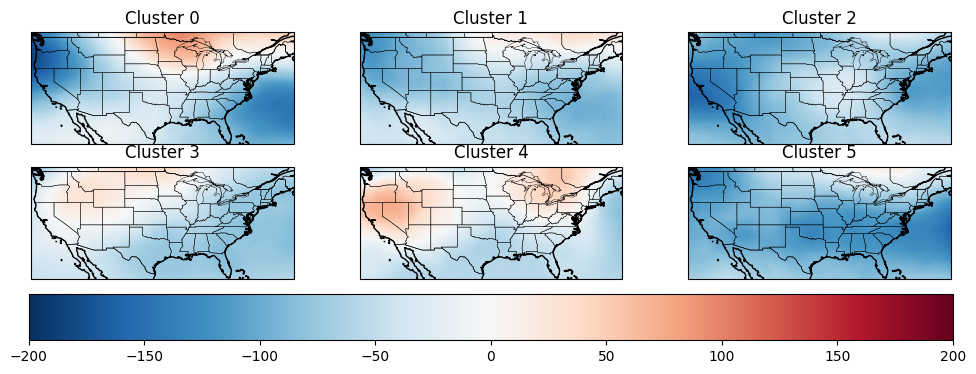

In [67]:
# visualize
n_clusters = comp_km.sizes['cluster']

fig, axes = plt.subplots(
    nrows=2, ncols=3,  # adjust to match cluster count
    figsize=(12, 4),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

axes = axes.ravel()

for i, ax in enumerate(axes[:n_clusters]):
    field = comp_km.isel(cluster=i)

    im = ax.pcolormesh(
        field['longitude'],
        field['latitude'],
        field,
        transform=ccrs.PlateCarree(),
        cmap='RdBu_r',
        vmin=-200,
        vmax=200
    )

    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.STATES, linewidth=0.3)

    ax.set_title(f'Cluster {i}')

# shared colorbar
fig.colorbar(im, ax=axes.tolist(), orientation='horizontal', pad=0.05)

plt.show()

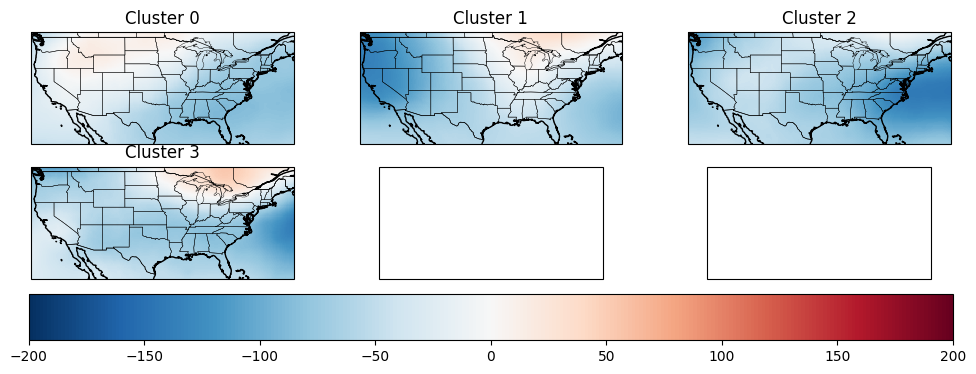

In [68]:
n_clusters = comp_som.sizes['cluster']

fig, axes = plt.subplots(
    nrows=2, ncols=3,  # adjust to match cluster count
    figsize=(12, 4),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

axes = axes.ravel()

for i, ax in enumerate(axes[:n_clusters]):
    field = comp_som.isel(cluster=i)

    im = ax.pcolormesh(
        field['longitude'],
        field['latitude'],
        field,
        transform=ccrs.PlateCarree(),
        cmap='RdBu_r',
        vmin=-200,
        vmax=200
    )

    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.STATES, linewidth=0.3)

    ax.set_title(f'Cluster {i}')

# shared colorbar
fig.colorbar(im, ax=axes.tolist(), orientation='horizontal', pad=0.05)

plt.show()